In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Q1: How many qualitative and quantitative variables? Appropriate visuals and correlation measures?
Q2: Howare variables correlatedto each other? Groups of correlated variables?
Q3: How are properties distributed according to their surface?

C:\Users\Home\AppData\Local\Temp\ipykernel_31360\2777705393.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels([f"{lbl}\n(n={n[lbl]})" for lbl in ["Non prestigieuse", "Prestigieuse"]])


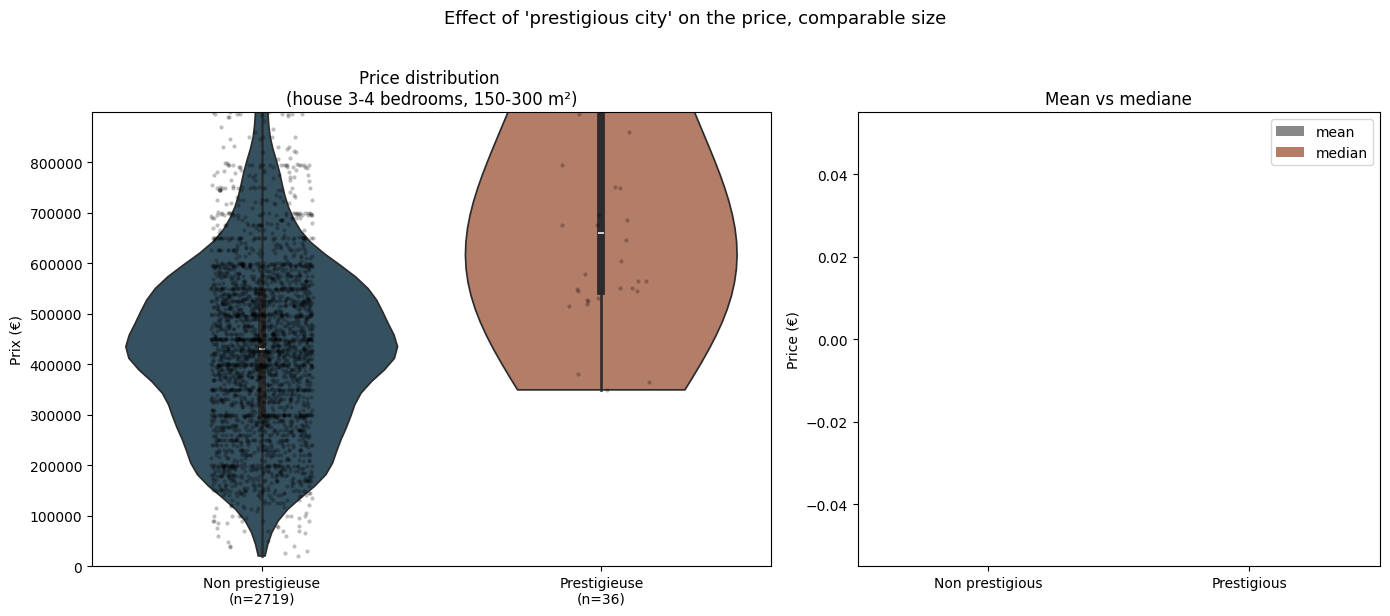

                  count      mean    median       std
prestigieuse                                         
Non prestigieuse   2719  437976.0  429000.0  191932.0
Prestigieuse         36  783819.0  660000.0  459644.0


In [ ]:
df = pd.read_csv("../data/raw/properties_cleaned.csv")
quant_vars = [
    "price", "living_area_m2", "total_area_m2", "garden_area_m2",
    "bedrooms", "bathrooms", "building_year", "parking_count",
    "facades", "floors_total", "floor_number", "km_from_nearby_city",
]
quali_nominale = [
    "property_type", "property_subtype", "state_of_the_building",
    "kitchen_equipped", "epc_score", "region", "province", "city",
    "nearby_city", "postal_code",
]
quali_binaire = [
    "furnished", "has_garage", "has_elevator", "has_garden",
    "has_terrace", "is_nearby_city_prestigious",
]
quali_vars = quali_nominale + quali_binaire

# 2. Violin plot

h = df[df["property_type"] == "House"].dropna(
    subset=["is_nearby_city_prestigious", "price", "living_area_m2", "bedrooms"]
).copy()
h = h[h["bedrooms"].isin([3, 4])]
h = h[h["living_area_m2"].between(150,300)]
 
h["prestigieuse"] = h["is_nearby_city_prestigious"].map({0.0: "Non prestigieuse", 1.0: "Prestigieuse"})
n = h["prestigieuse"].value_counts()
cap = h["price"].quantile(0.98)
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [1.3, 1]})
 
# Violin + points individuels (strip) pour voir aussi les effectifs réels
sns.violinplot(data=h, x="prestigieuse", y="price", ax=axes[0], cut=0,
                hue="prestigieuse", legend=False,
                palette={"Non prestigieuse": "#2E5266", "Prestigieuse": "#C0775B"})
sns.stripplot(data=h, x="prestigieuse", y="price", ax=axes[0],
              color="black", alpha=0.25, size=3, jitter=0.15)
axes[0].set_ylim(0, cap)
axes[0].set_xlabel("")
axes[0].set_ylabel("Prix (€)")
axes[0].set_xticklabels([f"{lbl}\n(n={n[lbl]})" for lbl in ["Non prestigieuse", "Prestigieuse"]])
axes[0].set_title("Price distribution \n(house 3-4 bedrooms, 150-300 m²)")
 
# Barres moyenne/médiane côte à côte pour lire l'écart directement
summary = h.groupby("prestigious")["price"].agg(["mean", "median"]).reindex(
    ["Non prestigious", "Prestigious"])
summary_plot = summary.reset_index().melt(id_vars="prestigious", var_name="stat", value_name="prix")
sns.barplot(data=summary_plot, x="prestigieuse", y="prix", hue="stat", ax=axes[1],
            palette=["#888888", "#C0775B"])
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.0f€", fontsize=8, padding=2)
axes[1].set_xlabel("")
axes[1].set_ylabel("Price (€)")
axes[1].set_title("Mean vs mediane")
axes[1].legend(title="")
 
plt.suptitle("Effect of 'prestigious city' on the price, comparable size", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
 
print(h.groupby("prestigieuse")["price"].agg(["count", "mean", "median", "std"]).round(0))